In [1]:
import numpy
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.transforms as transforms
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import random_split
from torch.utils.data import DataLoader

In [2]:
import torch

print(torch.__version__)
print("CUDA dostępna:", torch.cuda.is_available())
print("Wersja CUDA w torch:", torch.version.cuda)
print("Liczba GPU:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

2.8.0+cu128
CUDA dostępna: True
Wersja CUDA w torch: 12.8
Liczba GPU: 1
GPU: NVIDIA GeForce RTX 3060 Laptop GPU


In [3]:
torch.manual_seed(42)  # For reproducibility

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
from pathlib import Path

base = Path("data/prepared_data256")

print("Czy istnieje base?", base.exists())
print("Czy istnieje images?", (base / "images").exists())
print("Czy istnieje masks?", (base / "masks").exists())

print("Pliki w base:")
print(list(base.glob("*")))

print("Pliki w images:")
print(list((base / "images").glob("*"))[:10])

print("Pliki w masks:")
print(list((base / "masks").glob("*"))[:10])

Czy istnieje base? True
Czy istnieje images? True
Czy istnieje masks? True
Pliki w base:
[WindowsPath('data/prepared_data256/images'), WindowsPath('data/prepared_data256/masks')]
Pliki w images:
[WindowsPath('data/prepared_data256/images/image_part_001_0.png'), WindowsPath('data/prepared_data256/images/image_part_001_1.png'), WindowsPath('data/prepared_data256/images/image_part_001_10.png'), WindowsPath('data/prepared_data256/images/image_part_001_11.png'), WindowsPath('data/prepared_data256/images/image_part_001_12.png'), WindowsPath('data/prepared_data256/images/image_part_001_13.png'), WindowsPath('data/prepared_data256/images/image_part_001_14.png'), WindowsPath('data/prepared_data256/images/image_part_001_15.png'), WindowsPath('data/prepared_data256/images/image_part_001_16.png'), WindowsPath('data/prepared_data256/images/image_part_001_17.png')]
Pliki w masks:
[WindowsPath('data/prepared_data256/masks/image_part_001_0.png'), WindowsPath('data/prepared_data256/masks/image_part_001

In [5]:
from pathlib import Path
from sklearn.model_selection import train_test_split

images = sorted(Path("data/prepared_data256/images").glob("*.png"))
masks = sorted(Path("data/prepared_data256/masks").glob("*.png"))

pairs = list(zip(images, masks))
print(pairs)
train_pairs, temp_pairs = train_test_split(
    pairs,
    test_size=0.3,
    random_state=42,
    shuffle=True
)

val_pairs, test_pairs = train_test_split(
    temp_pairs,
    test_size=0.5,
    random_state=42,
    shuffle=True
)

print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

[(WindowsPath('data/prepared_data256/images/image_part_001_0.png'), WindowsPath('data/prepared_data256/masks/image_part_001_0.png')), (WindowsPath('data/prepared_data256/images/image_part_001_1.png'), WindowsPath('data/prepared_data256/masks/image_part_001_1.png')), (WindowsPath('data/prepared_data256/images/image_part_001_10.png'), WindowsPath('data/prepared_data256/masks/image_part_001_10.png')), (WindowsPath('data/prepared_data256/images/image_part_001_11.png'), WindowsPath('data/prepared_data256/masks/image_part_001_11.png')), (WindowsPath('data/prepared_data256/images/image_part_001_12.png'), WindowsPath('data/prepared_data256/masks/image_part_001_12.png')), (WindowsPath('data/prepared_data256/images/image_part_001_13.png'), WindowsPath('data/prepared_data256/masks/image_part_001_13.png')), (WindowsPath('data/prepared_data256/images/image_part_001_14.png'), WindowsPath('data/prepared_data256/masks/image_part_001_14.png')), (WindowsPath('data/prepared_data256/images/image_part_001_

In [6]:
import random
import torchvision.transforms.functional as TF

class SegementationTransform():
    def __init__(self,hflip_prob=0.5,vflip_prob=0.5):
        self.hflip_prob = hflip_prob
        self.vflip_prob =vflip_prob

In [7]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF


class AerialSegemntationDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)
    
    def __getitem__(self, index):
        image_path, mask_path = self.pairs[index]

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path)

        if self.transform is not None:
            image, mask = self.transform(image, mask)

        image = TF.to_tensor(image)
        mask = torch.as_tensor(np.array(mask), dtype=torch.long)

        return image, mask

In [8]:
from torch.utils.data import DataLoader

train_dataset = AerialSegemntationDataset(train_pairs)

train_loader = DataLoader(train_dataset,batch_size=8,shuffle=True,num_workers=0)

val_dataset = AerialSegemntationDataset(val_pairs)

val_loader = DataLoader(val_dataset,batch_size=8,shuffle=False,num_workers=0)

test_dataset = AerialSegemntationDataset(test_pairs)

test_loader = DataLoader(test_dataset,batch_size=8,shuffle=False,num_workers=0)

In [9]:
class UNet(nn.Module):
    def __init__(self, n_class,inuput_channels):
        super().__init__()
        #Encoding
        self.e11 = nn.Conv2d(inuput_channels, 64, kernel_size=3, padding=1, bias=False)
        self.e12 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.pool1 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e21 = nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False)
        self.e22 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.pool2 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e31 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.e32 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.pool3 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e41 = nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False)
        self.e42 = nn.Conv2d(512, 512, kernel_size=3, padding=1, bias=False)
        self.pool4 = nn.MaxPool2d(kernel_size=2,stride=2) 

        self.e51 = nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False)
        self.e52 = nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False)

        #Decoding
        self.upconv1 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.d11 = nn.Conv2d(1024,512,kernel_size=3, padding=1)
        self.d12 = nn.Conv2d(512,512,kernel_size=3, padding=1)

        self.upconv2 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.d21 = nn.Conv2d(512,256,kernel_size=3, padding=1)
        self.d22 = nn.Conv2d(256,256,kernel_size=3, padding=1)

        self.upconv3 = nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.d31 = nn.Conv2d(256,128,kernel_size=3, padding=1)
        self.d32 = nn.Conv2d(128,128,kernel_size=3, padding=1)

        self.upconv4 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.d41 = nn.Conv2d(128,64,kernel_size=3, padding=1)
        self.d42 = nn.Conv2d(64,64,kernel_size=3, padding=1)

        #out
        self.outconv= nn.Conv2d(64,n_class,kernel_size=1)

    def forward(self,x):
        #encoder
        xe11 = nn.functional.relu(self.e11(x))
        xe12 = nn.functional.relu(self.e12(xe11))
        xp1 = self.pool1(xe12)

        xe21 = nn.functional.relu(self.e21(xp1))
        xe22 = nn.functional.relu(self.e22(xe21))
        xp2 = self.pool1(xe22)

        xe31 = nn.functional.relu(self.e31(xp2))
        xe32 = nn.functional.relu(self.e32(xe31))
        xp3 = self.pool1(xe32)

        xe41 = nn.functional.relu(self.e41(xp3))
        xe42 = nn.functional.relu(self.e42(xe41))
        xp4 = self.pool1(xe42)

        xe51 = nn.functional.relu(self.e51(xp4))
        xe52 = nn.functional.relu(self.e52(xe51))

        #decoder
        xu1 = self.upconv1(xe52)
        xu11 = torch.cat([xu1,xe42],dim=1)
        xd11 = nn.functional.relu(self.d11(xu11))
        xd12 = nn.functional.relu(self.d12(xd11))

        xu2 = self.upconv2(xd12)
        xu21 = torch.cat([xu2,xe32],dim=1)
        xd21 = nn.functional.relu(self.d21(xu21))
        xd22 = nn.functional.relu(self.d22(xd21))

        xu3 = self.upconv3(xd22)
        xu31 = torch.cat([xu3,xe22],dim=1)
        xd31 = nn.functional.relu(self.d31(xu31))
        xd32 = nn.functional.relu(self.d32(xd31))

        xu4 = self.upconv4(xd32)
        xu41 = torch.cat([xu4,xe12],dim=1)
        xd41 = nn.functional.relu(self.d41(xu41))
        xd42 = nn.functional.relu(self.d42(xd41))

        #out
        out = self.outconv(xd42)

        return out

        

In [10]:
from torchmetrics.classification import MulticlassJaccardIndex

class Trainer():
    def __init__(self,
                 model,
                 train_loader,
                 val_loader,
                 test_loader,
                 criterion,
                 optimizer,
                 num_epochs,
                 metric = MulticlassJaccardIndex(num_classes=6, average=None)
):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader = test_loader
        self.criterion = criterion
        self.optimizer = optimizer
        self.num_epochs = num_epochs
        self.metric = metric.to(device=device)

        self.train_loss_hist =[]
        self.val_loss_hist =[]
        self.train_miou_hist =[]
        self.val_miou_hist =[]

    def training_epoch(self, data_loader):
        self.model.train()
        running_loss = 0.0
        
        self.metric.reset()
        for image, mask in data_loader:
            image, mask = image.to(device), mask.to(device)

            self.optimizer.zero_grad()
            out = self.model(image)
            loss = self.criterion(out,mask)
            loss.backward()
            self.optimizer.step()
            

            running_loss += loss.item()
            pred = torch.argmax(out, dim=1)

            self.metric.update(pred, mask)

        loss = running_loss/len(data_loader)
        miou = self.metric.compute()
        return loss, miou.mean().item()

    def evaluate(self, data_loader):
        self.model.eval()
        running_loss = 0.0
        self.metric.reset()
        
        with torch.no_grad():
            for image, mask in data_loader:
                image, mask = image.to(device), mask.to(device)

                out = self.model(image)
                loss = self.criterion(out,mask)

                running_loss += loss.item()
                pred = torch.argmax(out, dim=1)

                self.metric.update(pred, mask)

        loss = running_loss/len(data_loader)
        miou = self.metric.compute()
        return loss, miou.mean().item()
    

    def train(self):

        for epoch in range(self.num_epochs):
            train_loss, train_miou = self.training_epoch(self.train_loader)
            val_loss, val_miou = self.evaluate(self.val_loader)

            self.train_loss_hist.append(train_loss)
            self.val_loss_hist.append(val_loss)
            self.train_miou_hist.append(train_miou)
            self.val_miou_hist.append(val_miou)

            print(f'Epoch [{epoch + 1}/{self.num_epochs}], '
                  f'Train Loss: {train_loss:.4f}, val loss: {val_loss:.2f} '
                  f'Train miou: {train_miou:.4f}, val miou: {val_miou:.2f} ')
            
    def show_history(self):
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].plot(range(self.num_epochs), np.array(self.train_loss_hist), color='blue', label='Train Loss')
        axes[0].plot(range(self.num_epochs), np.array(self.val_loss_hist), color='red', label='Val Loss')
        axes[0].set_title("Trening: Funkcja straty")
        axes[0].set_xlabel("epoch")
        axes[0].set_ylabel("loss")  
        axes[0].legend()
        
        axes[1].plot(range(self.num_epochs), np.array(self.train_miou_hist), color='blue', label='Train mIoU')
        axes[1].plot(range(self.num_epochs), np.array(self.val_miou_hist), color='red', label='Val mIoU')
        axes[1].set_title("Trening: miou")
        axes[1].set_xlabel("epoch")
        axes[1].set_ylabel("mIoU")   
        axes[1].legend() 
        
        plt.tight_layout()
        plt.show()


    def get_history(self):
        return self.train_loss_hist,self.val_loss_hist,self.train_miou_hist,self.val_miou_hist


c:\Users\plejc\anaconda3\envs\dnn\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
modelUnet = UNet(n_class=6,inuput_channels=3).to(device)
UNet_Aerial_trainer = Trainer(model=modelUnet,
                              train_loader=train_loader,
                              val_loader=val_loader,
                              test_loader=test_loader,
                              criterion=nn.CrossEntropyLoss(),
                              optimizer=optim.Adam(modelUnet.parameters(), lr=0.001),
                              num_epochs=100,
                              metric = MulticlassJaccardIndex(num_classes=6, average=None))
UNet_Aerial_trainer.train()

Epoch [1/100], Train Loss: 1.5032, val loss: 1.04 Train miou: 0.0897, val miou: 0.10 
Epoch [2/100], Train Loss: 1.0623, val loss: 0.98 Train miou: 0.1153, val miou: 0.12 
Epoch [3/100], Train Loss: 0.9120, val loss: 0.81 Train miou: 0.2567, val miou: 0.35 
Epoch [4/100], Train Loss: 0.7783, val loss: 0.78 Train miou: 0.3841, val miou: 0.36 
Epoch [5/100], Train Loss: 0.7467, val loss: 0.75 Train miou: 0.3964, val miou: 0.40 
Epoch [6/100], Train Loss: 0.7357, val loss: 0.72 Train miou: 0.4111, val miou: 0.41 
Epoch [7/100], Train Loss: 0.7346, val loss: 0.79 Train miou: 0.4110, val miou: 0.37 
Epoch [8/100], Train Loss: 0.7311, val loss: 0.88 Train miou: 0.4235, val miou: 0.38 
Epoch [9/100], Train Loss: 0.7437, val loss: 0.76 Train miou: 0.4191, val miou: 0.40 
Epoch [10/100], Train Loss: 1.7551, val loss: 0.92 Train miou: 0.2032, val miou: 0.28 
Epoch [11/100], Train Loss: 0.9162, val loss: 0.96 Train miou: 0.2722, val miou: 0.35 
Epoch [12/100], Train Loss: 0.7979, val loss: 0.81 T

In [12]:
# Zapis modelu po zakończeniu treningu

import torch
import os

os.makedirs("saved_models", exist_ok=True)

MODEL_PATH = "saved_models/unet_aerial_model.pth"

torch.save(modelUnet.state_dict(), MODEL_PATH)

print(f"Model zapisany do: {MODEL_PATH}")

Model zapisany do: saved_models/unet_aerial_model.pth


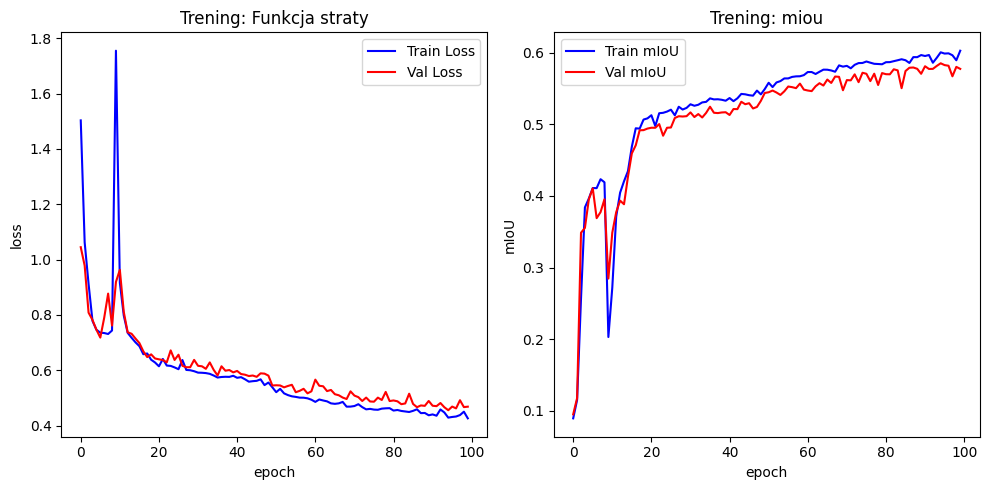

In [13]:
UNet_Aerial_trainer.show_history()

In [14]:
modelUnet.eval()

images, masks = next(iter(test_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():
    logits = modelUnet(images)          # [B, 6, H, W]
    preds = torch.argmax(logits, dim=1) # [B, H, W]

print("images:", images.shape)
print("masks:", masks.shape)
print("logits:", logits.shape)
print("preds:", preds.shape)

print("Mask unique:", masks.unique())
print("Pred unique:", preds.unique())

images: torch.Size([8, 3, 256, 256])
masks: torch.Size([8, 256, 256])
logits: torch.Size([8, 6, 256, 256])
preds: torch.Size([8, 256, 256])
Mask unique: tensor([0, 1, 2, 3, 5], device='cuda:0')
Pred unique: tensor([0, 1, 2, 3, 4], device='cuda:0')


In [15]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_COLORS = {
    0: (60, 16, 152),     # Building
    1: (132, 41, 246),    # Land
    2: (110, 193, 228),   # Road
    3: (254, 221, 58),    # Vegetation
    4: (226, 169, 41),    # Water
    5: (155, 155, 155),   # Unlabeled
}


def class_mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)

    for class_idx, color in CLASS_COLORS.items():
        rgb[mask == class_idx] = color

    return rgb

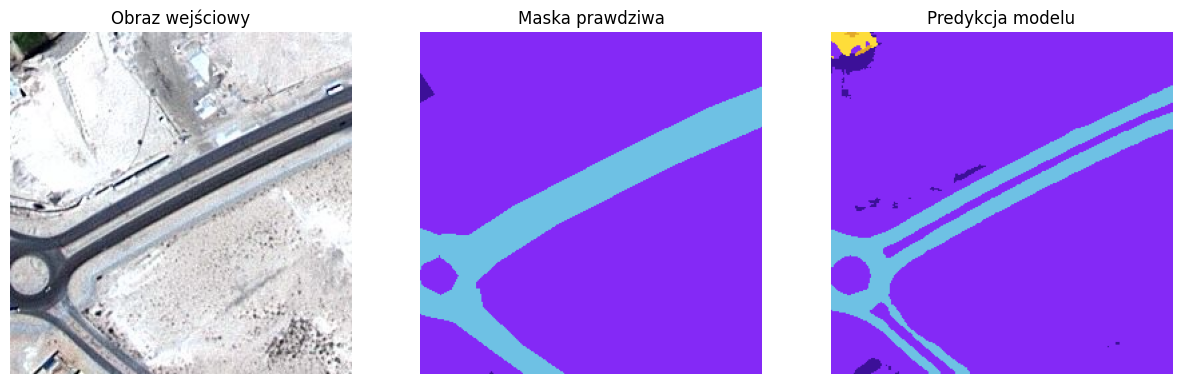

In [16]:
idx = 0

image_np = images[idx].detach().cpu().permute(1, 2, 0).numpy()
mask_np = masks[idx].detach().cpu().numpy()
pred_np = preds[idx].detach().cpu().numpy()

mask_rgb = class_mask_to_rgb(mask_np)
pred_rgb = class_mask_to_rgb(pred_np)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(image_np)
plt.title("Obraz wejściowy")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask_rgb)
plt.title("Maska prawdziwa")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred_rgb)
plt.title("Predykcja modelu")
plt.axis("off")

plt.show()

=== Podsumowanie metryk na zbiorze testowym ===


,Metryka,Wartość
0,Loss,0.447318
1,Pixel accuracy,0.848782
2,Mean pixel accuracy,0.824322
3,Mean precision,0.849600
4,Mean recall,0.824322
5,Mean specificity,0.953678
6,Mean F1 / Dice,0.835655
7,Mean IoU,0.723091
8,Weighted F1 / Dice,0.850633
9,Weighted IoU,0.744451


=== Metryki dla poszczególnych klas ===


,Klasa,Piksele GT,Piksele przewidziane,Udział GT [%],Pixel accuracy,Precision,Recall,Specificity,F1 / Dice,IoU / Jaccard
0,Building,939063,956850,18.853900,0.803236,0.788304,0.803236,0.949882,0.795700,0.660716
1,Land,2542209,2630316,51.040830,0.916554,0.885852,0.916554,0.876875,0.900942,0.819740
2,Road,536267,456862,10.766822,0.697481,0.818707,0.697481,0.981364,0.753248,0.604168
3,Vegetation,783139,800188,15.723359,0.815287,0.797916,0.815287,0.961477,0.806508,0.675755
4,Water,146988,136520,2.951130,0.889052,0.957222,0.889052,0.998792,0.921879,0.855079
5,Unlabeled,33070,0,0.663958,0.000000,NaN,0.000000,1.000000,0.000000,0.000000


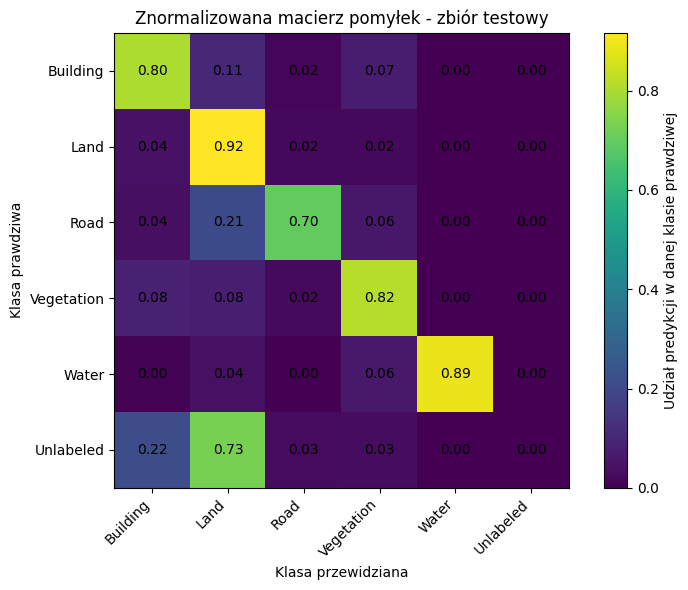

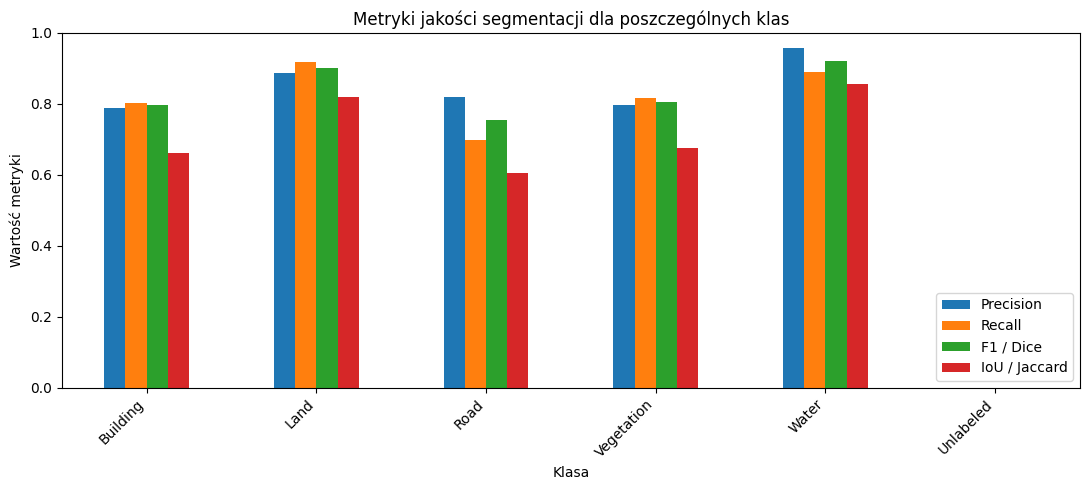

Zapisano pliki:
- metryki_podsumowanie_test.csv
- metryki_klasy_test.csv


In [ ]:
# =========================
# Pełna ocena modelu na zbiorze testowym
# =========================

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Nazwy klas zgodne z kolorami używanymi wcześniej w notebooku
CLASS_NAMES = {
    0: "Building",
    1: "Land",
    2: "Road",
    3: "Vegetation",
    4: "Water",
    5: "Unlabeled",
}

NUM_CLASSES = 6

# Jeżeli klasa 5 oznacza tło/obszar nieopisany, zwykle warto NIE liczyć jej do średnich.
# Jeśli chcesz liczyć wszystkie klasy w średnich, ustaw: IGNORE_CLASS_FOR_MEAN = None
IGNORE_CLASS_FOR_MEAN = 5


def safe_divide(numerator, denominator):
    """Dzielenie odporne na dzielenie przez zero; zwraca NaN tam, gdzie mianownik = 0."""
    numerator = np.asarray(numerator, dtype=np.float64)
    denominator = np.asarray(denominator, dtype=np.float64)
    return np.divide(
        numerator,
        denominator,
        out=np.full_like(numerator, np.nan, dtype=np.float64),
        where=denominator != 0
    )


def evaluate_segmentation_model(
    model,
    data_loader,
    num_classes=6,
    class_names=None,
    criterion=None,
    device=None,
    ignore_class_for_mean=None,
):
    """
    Liczy metryki dla segmentacji semantycznej:
    - loss,
    - pixel accuracy,
    - mean pixel accuracy,
    - precision,
    - recall,
    - specificity,
    - F1/Dice,
    - IoU/Jaccard,
    - mean IoU,
    - frequency weighted IoU,
    - macierz pomyłek.
    """

    if device is None:
        device = next(model.parameters()).device

    model.eval()

    confusion_matrix = torch.zeros((num_classes, num_classes), dtype=torch.int64)
    total_loss = 0.0
    number_of_batches = 0

    with torch.no_grad():
        for images, masks in data_loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)

            if criterion is not None:
                loss = criterion(logits, masks)
                total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            # Spłaszczenie masek i predykcji: [B, H, W] -> [B*H*W]
            true = masks.detach().view(-1).cpu()
            pred = preds.detach().view(-1).cpu()

            # Zabezpieczenie: liczymy tylko piksele o etykietach 0..num_classes-1
            valid = (true >= 0) & (true < num_classes)
            true = true[valid]
            pred = pred[valid]

            # Wiersze = klasa prawdziwa, kolumny = klasa przewidziana
            encoded = num_classes * true + pred
            confusion_matrix += torch.bincount(
                encoded,
                minlength=num_classes ** 2
            ).reshape(num_classes, num_classes)

            number_of_batches += 1

    cm = confusion_matrix.numpy().astype(np.float64)

    total_pixels = cm.sum()
    tp = np.diag(cm)
    support = cm.sum(axis=1)       # ile pikseli naprawdę należy do danej klasy
    predicted = cm.sum(axis=0)     # ile pikseli model przypisał do danej klasy

    fp = predicted - tp
    fn = support - tp
    tn = total_pixels - tp - fp - fn

    pixel_accuracy = float(safe_divide(tp.sum(), total_pixels))

    expected_accuracy = float(safe_divide(np.sum(support * predicted), total_pixels ** 2))
    cohen_kappa = float(safe_divide(pixel_accuracy - expected_accuracy, 1 - expected_accuracy))

    class_accuracy = safe_divide(tp, support)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)
    f1_dice = safe_divide(2 * tp, 2 * tp + fp + fn)
    iou = safe_divide(tp, tp + fp + fn)

    valid_classes_for_mean = support > 0
    if ignore_class_for_mean is not None:
        valid_classes_for_mean[ignore_class_for_mean] = False

    mean_pixel_accuracy = np.nanmean(class_accuracy[valid_classes_for_mean])
    mean_precision = np.nanmean(precision[valid_classes_for_mean])
    mean_recall = np.nanmean(recall[valid_classes_for_mean])
    mean_specificity = np.nanmean(specificity[valid_classes_for_mean])
    mean_f1_dice = np.nanmean(f1_dice[valid_classes_for_mean])
    mean_iou = np.nanmean(iou[valid_classes_for_mean])

    class_frequency = safe_divide(support, total_pixels)
    frequency_weighted_iou = np.nansum(class_frequency[valid_classes_for_mean] * iou[valid_classes_for_mean])

    weighted_f1_dice = np.nansum(
        safe_divide(support[valid_classes_for_mean], support[valid_classes_for_mean].sum())
        * f1_dice[valid_classes_for_mean]
    )

    weighted_iou = np.nansum(
        safe_divide(support[valid_classes_for_mean], support[valid_classes_for_mean].sum())
        * iou[valid_classes_for_mean]
    )

    average_loss = None
    if criterion is not None and number_of_batches > 0:
        average_loss = total_loss / number_of_batches

    labels = [
        class_names.get(i, f"Klasa {i}") if class_names is not None else f"Klasa {i}"
        for i in range(num_classes)
    ]

    per_class_df = pd.DataFrame({
        "Klasa": labels,
        "Piksele GT": support.astype(np.int64),
        "Piksele przewidziane": predicted.astype(np.int64),
        "Udział GT [%]": safe_divide(support, total_pixels) * 100,
        "Pixel accuracy": class_accuracy,
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1 / Dice": f1_dice,
        "IoU / Jaccard": iou,
    })

    summary_df = pd.DataFrame({
        "Metryka": [
            "Loss",
            "Pixel accuracy",
            "Mean pixel accuracy",
            "Mean precision",
            "Mean recall",
            "Mean specificity",
            "Mean F1 / Dice",
            "Mean IoU",
            "Weighted F1 / Dice",
            "Weighted IoU",
            "Frequency weighted IoU",
            "Cohen kappa",
        ],
        "Wartość": [
            average_loss,
            pixel_accuracy,
            mean_pixel_accuracy,
            mean_precision,
            mean_recall,
            mean_specificity,
            mean_f1_dice,
            mean_iou,
            weighted_f1_dice,
            weighted_iou,
            frequency_weighted_iou,
            cohen_kappa,
        ]
    })

    return per_class_df, summary_df, cm


# Liczenie metryk na zbiorze testowym
loss_function = nn.CrossEntropyLoss()

per_class_metrics, summary_metrics, confusion_matrix = evaluate_segmentation_model(
    model=modelUnet,
    data_loader=test_loader,
    num_classes=NUM_CLASSES,
    class_names=CLASS_NAMES,
    criterion=loss_function,
    device=device,
    ignore_class_for_mean=IGNORE_CLASS_FOR_MEAN,
)

print("=== Podsumowanie metryk na zbiorze testowym ===")
display(summary_metrics)

print("=== Metryki dla poszczególnych klas ===")
display(per_class_metrics)


# =========================
# Macierz pomyłek
# =========================

labels = [CLASS_NAMES[i] for i in range(NUM_CLASSES)]

# Normalizacja po wierszach, czyli względem klas prawdziwych
row_sums = confusion_matrix.sum(axis=1, keepdims=True)
confusion_matrix_normalized = np.divide(
    confusion_matrix,
    row_sums,
    out=np.zeros_like(confusion_matrix, dtype=np.float64),
    where=row_sums != 0
)

plt.figure(figsize=(8, 6))
plt.imshow(confusion_matrix_normalized)
plt.title("Znormalizowana macierz pomyłek-zbiór testowy")
plt.xlabel("Klasa przewidziana")
plt.ylabel("Klasa prawdziwa")
plt.xticks(range(NUM_CLASSES), labels, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), labels)
plt.colorbar(label="Udział predykcji w danej klasie prawdziwej")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, f"{confusion_matrix_normalized[i, j]:.2f}",
                 ha="center", va="center")

plt.tight_layout()
plt.show()


# =========================
# Wykres najważniejszych metryk klasowych
# =========================

plot_df = per_class_metrics.set_index("Klasa")[["Precision", "Recall", "F1 / Dice", "IoU / Jaccard"]]

ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.set_title("Metryki jakości segmentacji dla poszczególnych klas")
ax.set_xlabel("Klasa")
ax.set_ylabel("Wartość metryki")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# =========================
# Zapis wyników do plików CSV
# =========================

summary_metrics.to_csv("metryki_podsumowanie_test.csv", index=False)
per_class_metrics.to_csv("metryki_klasy_test.csv", index=False)

print("Zapisano pliki:")
print("- metryki_podsumowanie_test.csv")
print("- metryki_klasy_test.csv")
